In [1]:
import pandas as pd

# PFAS Cost-Risk Analysis

## Overview
This notebook analyzes the cost-effectiveness of different PFAS treatment scenarios using UCMR5 data.

## Starting Dataset
- Source: `ep_table` from `analysis.ipynb`
- Systems: 26,148 FacilityID(Entry Points), 10,155 PWSID(water systems) with population data


## Objectives
1. Estimate treatment costs for varying regulatory thresholds (4, 8, 12, 20, 40 ng/L)
2. Calculate risk reduction (ng×person/day) for each scenario
3. Determine the cost-effectiveness of different treatment targets
4. Visualize trade-offs between costs and public health benefits

In [2]:
df = pd.read_csv('ep_table.csv')

In [3]:
df.head()

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population,Population_bin
0,AK2110342,29349,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
1,AK2110342,29360,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
2,AK2110601,10001,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
3,AK2110601,10004,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
4,AK2120232,TP001,0.0,0.0,False,8937.0,8937.0,"3,301 - 10,000"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26148 entries, 0 to 26147
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PWSID                    26148 non-null  object 
 1   FacilityID               26148 non-null  object 
 2   PFOA                     26148 non-null  float64
 3   PFOS                     26148 non-null  float64
 4   exceeds                  26148 non-null  bool   
 5   POPULATION_SERVED_COUNT  26148 non-null  float64
 6   Ep_Population            26148 non-null  float64
 7   Population_bin           26148 non-null  object 
dtypes: bool(1), float64(4), object(3)
memory usage: 1.4+ MB


In [5]:
total_exceeding_facilities = df["exceeds"].sum()

print(f'Total PWSID -> {df['PWSID'].nunique()}')
print(f'Total FacilityID (Entry Points) -> {len(df)}')
print(f'Entry points exceeding 80% Threshold (more than 0.0032 µg/L threshold)-> {total_exceeding_facilities}')
print(f"Percentage: {total_exceeding_facilities / len(df) * 100:.1f}%")

Total PWSID -> 10155
Total FacilityID (Entry Points) -> 26148
Entry points exceeding 80% Threshold (more than 0.0032 µg/L threshold)-> 2214
Percentage: 8.5%


### PFAS Threshold Exceedance (4–40 ng/L)

Our dataset reports PFOA and PFOS in µg/L, we convert thresholds from ng/L → µg/L:

- 4 ng/L → 0.004 µg/L  
- 8 ng/L → 0.008 µg/L  
- 12 ng/L → 0.012 µg/L  
- 20 ng/L → 0.020 µg/L  
- 40 ng/L → 0.040 µg/L  


For each threshold, we create a column (`exceeds_4`, `exceeds_8`, …) that is True if `PFOA` or `PFOS`  exceeds the converted value.

These columns define which systems would require treatment under different regulatory scenarios.


In [6]:
df['Total_PFAS'] = df['PFOA'] + df['PFOS']

In [7]:
threshold_ng = [4,8,12,20,40]

for t in threshold_ng:
    col_name = f"exceeds_{t}"
    threshold_ug = t / 1000 # convert ng/L ->  µg/L
    df[col_name] = (df['PFOA'] > threshold_ug) | (df['PFOS'] > threshold_ug)

In [8]:
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,Total_PFAS,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
839,AL0001507,90106,0.000,0.00000,False,14052.0,2342.000000,"1,001 - 3,300",0.00000,False,False,False,False,False
9,AK2210906,32655,0.000,0.00000,False,221351.0,20122.818182,"10,001 - 50,000",0.00000,False,False,False,False,False
14146,MT0000241,00003,0.000,0.00000,False,32091.0,10697.000000,"10,001 - 50,000",0.00000,False,False,False,False,False
25770,WI4360364,00081,0.000,0.00000,False,34500.0,34500.000000,"10,001 - 50,000",0.00000,False,False,False,False,False
8948,IL1610700,17080,0.000,0.00000,False,7473.0,7473.000000,"3,301 - 10,000",0.00000,False,False,False,False,False
3964,CA3410029,91810,0.006,0.00445,True,184896.0,9731.368421,"3,301 - 10,000",0.01045,True,False,False,False,False
11751,MI0002310,10920,0.000,0.00000,False,81252.0,40626.000000,"10,001 - 50,000",0.00000,False,False,False,False,False
16311,NM3508317,94017,0.000,0.00000,False,20880.0,6960.000000,"3,301 - 10,000",0.00000,False,False,False,False,False
20812,TN0000572,TP003,0.000,0.00000,False,6050.0,3025.000000,"1,001 - 3,300",0.00000,False,False,False,False,False
13790,MS0450013,32720,0.000,0.00000,False,24459.0,3494.142857,"3,301 - 10,000",0.00000,False,False,False,False,False


In [9]:
# rearranging the columns
df = df[
    [
        "PWSID",
        "FacilityID",
        "PFOA",
        "PFOS",
        "Total_PFAS",
        "POPULATION_SERVED_COUNT",
        "Ep_Population",
        "Population_bin",
        "exceeds",
        "exceeds_4",
        "exceeds_8",
        "exceeds_12",
        "exceeds_20",
        "exceeds_40",
    ]
]
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
25395,WA5394900,02780,0.00000,0.00000,0.00000,18280.0,6093.333333,"3,301 - 10,000",False,False,False,False,False,False
7309,GA1570117,15797,0.00000,0.00000,0.00000,33601.0,11200.333333,"10,001 - 50,000",False,False,False,False,False,False
1771,AZ0410164,22240,0.00000,0.00000,0.00000,42316.0,3022.571429,"1,001 - 3,300",False,False,False,False,False,False
19710,PA7360140,103,0.00685,0.00000,0.00685,7734.0,2578.000000,"1,001 - 3,300",True,True,False,False,False,False
10652,LA1117025,20001,0.00000,0.00000,0.00000,840.0,280.000000,101 - 500,False,False,False,False,False,False
24197,UTAH29019,TP001,0.00000,0.00000,0.00000,8516.0,2129.000000,"1,001 - 3,300",False,False,False,False,False,False
11165,MA4126000,10018,0.00000,0.00000,0.00000,39144.0,7828.800000,"3,301 - 10,000",False,False,False,False,False,False
24793,WA5325200,14035,0.00000,0.00000,0.00000,36168.0,2782.153846,"1,001 - 3,300",False,False,False,False,False,False
7996,IA7727031,90003,0.00000,0.00000,0.00000,246055.0,82018.333333,"50,001 - 100,000",False,False,False,False,False,False
17625,NY5110526,00664,0.00575,0.00245,0.00820,1100000.0,4545.454545,"3,301 - 10,000",True,True,False,False,False,False


In [10]:
# Ep_Population is population served per entry point (total population / number of entry points)
# This calculation produces floats, so we round to whole numbers for clarity
df['Ep_Population'] = df['Ep_Population'].round()

In [11]:
print("=== Number of Entry Points Exceeding Each Threshold ===")
for t in threshold_ng:
    col = f"exceeds_{t}"
    count = df[col].sum()
    percent = (count / len(df)) * 100
    pop = df.loc[df[col] == 1, "Ep_Population"].sum()
    print(f"{t} ng/L: {count:,} FacilityId/EntryPoints ({percent:.2f}%), Population affected: {pop:,}")

=== Number of Entry Points Exceeding Each Threshold ===
4 ng/L: 2,078 FacilityId/EntryPoints (7.95%), Population affected: 28,772,056.0
8 ng/L: 944 FacilityId/EntryPoints (3.61%), Population affected: 13,123,092.0
12 ng/L: 481 FacilityId/EntryPoints (1.84%), Population affected: 7,923,771.0
20 ng/L: 186 FacilityId/EntryPoints (0.71%), Population affected: 2,995,707.0
40 ng/L: 39 FacilityId/EntryPoints (0.15%), Population affected: 307,375.0


### Risk Reduction Based on Drinking Water Intake (ng/day)

The EPA assumes the average adult consumes 2 liters per day of tap water.  
Therefore, PFAS exposure per facility id is estimated as:

$$
\text{ng/day total} = (\text{PFOA} + \text{PFOS})_{\mu g/L} 
\times 2\ \text{L/day/person} 
\times \text{Population Served} 
\times 1000\ \text{ng}/\mu g
$$


This value represents the total PFAS exposure per day for all people served by that entry point.


In [12]:
df["exposure_per_day(ng)"] = (df["Total_PFAS"] * 1000 * 2 * df["Ep_Population"])

In [13]:
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng)
10558,LA1103079,44006,0.0,0.0,0.0,17536.0,3507.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
6084,FL1370655,18005,0.0,0.0,0.0,200480.0,8019.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
19174,PA2640025,101,0.0,0.0,0.0,3775.0,755.0,"501 - 1,000",False,False,False,False,False,False,0.0
10199,LA1033005,44114,0.0,0.0,0.0,579714.0,14139.0,"10,001 - 50,000",False,False,False,False,False,False,0.0
1289,AZ0404034,10063,0.0,0.0,0.0,8013.0,668.0,"501 - 1,000",False,False,False,False,False,False,0.0
1193,AZ0402010,08608,0.0,0.0,0.0,20045.0,1336.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
9212,IN5214002,CC005,0.0,0.0,0.0,7969.0,2656.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
9817,KY0350134,0350134TPA,0.0,0.0,0.0,4583.0,4583.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
12654,MO1024005,CC80405,0.0,0.0,0.0,3580.0,1790.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
23089,TX1700638,00016,0.0,0.0,0.0,20016.0,2224.0,"1,001 - 3,300",False,False,False,False,False,False,0.0


In [14]:
# This adds up the total PFAS amount per day (ng/day) from all entry points
# that exceed each threshold.
pfas_exposure_by_threshold = {}

for t in threshold_ng:
    column = f"exceeds_{t}"
    ng_sum = (df['exposure_per_day(ng)'] * df[column]).sum()
    pfas_exposure_by_threshold[t] = round(float(ng_sum), 2)
    
pfas_exposure_by_threshold

{4: 852782850.93,
 8: 593140388.48,
 12: 442956224.78,
 20: 242658073.3,
 40: 40824148.7}

In [15]:
# sum the population served for all water systems (PWS) that exceed each PFAS regulatory threshold
population_by_threshold = {}

for t in threshold_ng:
    cols = f"exceeds_{t}"
    population_sum = df.loc[df[cols],'Ep_Population'].sum()
    population_by_threshold[t] = int(population_sum)
    
population_by_threshold

{4: 28772056, 8: 13123092, 12: 7923771, 20: 2995707, 40: 307375}

### Average PFAS Exposure Reduction (ng/day/person)

To describe how PFAS burden is distributed among affected populations, we divide the total PFAS burden proxy (ng/day) from all **entry points** exceeding a given threshold by the total population served by those entry points:

$$
\text{ng/day/person}_T
=
\frac{\text{ng/day total}_T}{\text{Population}_T}
$$

This represents the average PFAS mass per person per day among people served by Facility ID exceeding threshold \(T\).

In [16]:
# This calculates average PFAS per person per day for populations served
# by entry points exceeding each threshold.
ng_day_per_person = {}

for t in threshold_ng:
    total_ng = pfas_exposure_by_threshold[t]         # total ng/day
    total_pop = population_by_threshold[t]           # total population
    
  
    value = (total_ng / total_pop) if total_pop > 0 else 0
    ng_day_per_person[t] = round(value, 2)

ng_day_per_person

{4: 29.64, 8: 45.2, 12: 55.9, 20: 81.0, 40: 132.82}

### Comparing Corona and UCMR5

To align the UCMR5-based results with the Corona methodology, entry points exceeding 80% of the 4 ng/L threshold (3.2 ng/L) for either PFOA or PFOS were identified in UCMR5. These entry-point counts were compared against the total number of impacted entry points reported in Corona Table 3 (groundwater and surface water) for each population bin.


In [17]:
# mapping population bin with facility annualized cost column of Table 4 in the Corona memo

popbin_cost_map = {
    '25 - 100': 0.07,
    '101 - 500': 0.12,
    '501 - 1,000': 0.17,
    '1,001 - 3,300': 0.25,
    '3,301 - 10,000': 0.40,
    '10,001 - 50,000': 0.76,
    '50,001 - 100,000': 1.29,
    '100,001 - 1,000,000': 2.33,
    '> 1,000,000': 4.76
}

df['annualized_cost($M)'] = df['Population_bin'].map(popbin_cost_map)
df[['Population_bin', 'annualized_cost($M)']].head(10)

,Population_bin,annualized_cost($M)
0,"10,001 - 50,000",0.76
1,"10,001 - 50,000",0.76
2,"3,301 - 10,000",0.40
3,"3,301 - 10,000",0.40
4,"3,301 - 10,000",0.40
5,"3,301 - 10,000",0.40
6,"501 - 1,000",0.17
7,"10,001 - 50,000",0.76
8,"10,001 - 50,000",0.76
9,"10,001 - 50,000",0.76


In [18]:
# National entry-point counts from Corona Table 3 (GW + SW combined),
# used as the denominator for scaling UCMR5 entry-point results.
corona_table3 = {
    '25 - 100': 1800,
    '101 - 500': 2142,
    '501 - 1,000': 627,
    '1,001 - 3,300': 938,
    '3,301 - 10,000': 864,
    '10,001 - 50,000': 1091,
    '50,001 - 100,000': 326,
    '100,001 - 1,000,000': 458,
    '> 1,000,000': 67
}


In [19]:
# This table compares the number of UCMR5 entry points exceeding
# 80% of the 4 ng/L threshold (3.2 ng/L) to the total number of
# impacted entry points reported in Corona Table 3, by population bin.
rows = []

for pop in popbin_cost_map.keys():

    bin_df = df[df["Population_bin"] == pop]

    # UCMR5 entry points exceeding 80% of 4 ng/L (3.2 ng/L)
    ucmr5_count = bin_df["exceeds"].sum()


    # Corona national entry points
    corona_count = corona_table3[pop]

    percent_of_corona = ucmr5_count / corona_count

    rows.append({
        "population_bin": pop,
        "ucmr5_4x0.8": ucmr5_count,
        "corona_gw_sw": corona_count,
        "percent_of_corona": round(percent_of_corona, 3), #for display
        "percent_of_corona_raw": percent_of_corona #for calculation
    })

corona_comparison = pd.DataFrame(rows)
corona_comparison

,population_bin,ucmr5_4x0.8,corona_gw_sw,percent_of_corona,percent_of_corona_raw
0,25 - 100,9,1800,0.005,0.005000
1,101 - 500,30,2142,0.014,0.014006
2,"501 - 1,000",128,627,0.204,0.204147
3,"1,001 - 3,300",676,938,0.721,0.720682
4,"3,301 - 10,000",809,864,0.936,0.936343
5,"10,001 - 50,000",460,1091,0.422,0.421632
6,"50,001 - 100,000",57,326,0.175,0.174847
7,"100,001 - 1,000,000",45,458,0.098,0.098253
8,"> 1,000,000",0,67,0.000,0.000000


In [20]:
# This table reports the number of UCMR5 entry points exceeding each
# PFAS threshold (4, 8, 12, 20, 40 ng/L), grouped by population bin.
rows = []

for pop, cost in popbin_cost_map.items():
    # entry-point rows in this population bin
    bin_df = df[df["Population_bin"] == pop]

    row = {
        "population_bin": pop,
        "annualized_cost_per_facility ($M)": cost
    }

    # UCMR5 entry-point exceedance counts by threshold
    for t in threshold_ng:
        row[f"exceeds_{t}"] = int(bin_df[f"exceeds_{t}"].sum())

    rows.append(row)

comparison_table = pd.DataFrame(rows)
comparison_table


,population_bin,annualized_cost_per_facility ($M),exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
0,25 - 100,0.07,9,2,1,1,1
1,101 - 500,0.12,30,12,5,2,2
2,"501 - 1,000",0.17,124,59,38,16,3
3,"1,001 - 3,300",0.25,642,314,149,59,17
4,"3,301 - 10,000",0.40,761,317,149,54,8
5,"10,001 - 50,000",0.76,416,191,106,42,7
6,"50,001 - 100,000",1.29,53,30,18,9,1
7,"100,001 - 1,000,000",2.33,43,19,15,3,0
8,"> 1,000,000",4.76,0,0,0,0,0


### Scaling UCMR5 Results to All-U.S. Entry Points and National Cost Estimation

UCMR5 includes only a subset of U.S. drinking water entry points. Exceedance counts at the entry-point (Facility ID) level were scaled using Corona (Black & Veatch) population-bin ratios to estimate the total number of entry points nationwide exceeding PFAS thresholds (4, 8, 12, 20, and 40 ng/L).


In [21]:
comparison_scaled = comparison_table.merge(
    corona_comparison[["population_bin", "percent_of_corona_raw"]],
    on="population_bin",
    how="left"
)


In [22]:
for t in threshold_ng:
    comparison_scaled[f"proj_{t}"] = comparison_scaled.apply(
        lambda r: (r[f"exceeds_{t}"] / r["percent_of_corona_raw"])
        if pd.notna(r["percent_of_corona_raw"]) and r["percent_of_corona_raw"] > 0
        else 0,
        axis=1
    ).round(0)


In [23]:
for t in threshold_ng:
    comparison_scaled[f"proj_cost_{t} ($M)"] = (
        comparison_scaled[f"proj_{t}"] *
        comparison_scaled["annualized_cost_per_facility ($M)"]
    ).round(2)


In [24]:
national_costs_all_us = {
    t: round(float(comparison_scaled[f"proj_cost_{t} ($M)"].sum()), 2)
    for t in threshold_ng
}
national_costs_all_us


{4: 3195.71, 8: 1440.42, 12: 883.93, 20: 302.14, 40: 63.97}

We did this before, but because we are now scaling to Corona at the entry-point level, we repeat the scaling for PFAS burden and population.

In [25]:
# Corona-scaled national PFAS burden (ng/day), population, and ng/day/person

scaled_pfas_exposure_by_threshold = {}
scaled_population_by_threshold = {}
scaled_ng_day_per_person = {}

for t in threshold_ng:
    total_scaled_exposure = 0.0
    total_scaled_pop = 0.0

    for _, row in corona_comparison.iterrows():
        popbin = row["population_bin"]
        scale = row["percent_of_corona_raw"]

        if pd.isna(scale) or scale <= 0:
            continue  # skip bins with 0 coverage

        bin_mask = df["Population_bin"] == popbin

        # UCMR5 PFAS burden (ng/day) in this bin
        bin_exposure = (
            df.loc[bin_mask, "exposure_per_day(ng)"] *
            df.loc[bin_mask, f"exceeds_{t}"]
        ).sum()

        # UCMR5 population served in this bin
        bin_pop = (
            df.loc[bin_mask, "Ep_Population"] *
            df.loc[bin_mask, f"exceeds_{t}"]
        ).sum()

        # Scale to national estimate
        total_scaled_exposure += bin_exposure / scale
        total_scaled_pop += bin_pop / scale

    scaled_pfas_exposure_by_threshold[t] = round(float(total_scaled_exposure), 2)
    scaled_population_by_threshold[t] = round(float(total_scaled_pop), 0)
    scaled_ng_day_per_person[t] = round(
        float(total_scaled_exposure / total_scaled_pop) if total_scaled_pop > 0 else 0.0,
        2
    )


In [26]:
# Corona-scaled national PFAS burden proxy (ng/day) from entry points exceeding each threshold.
scaled_pfas_exposure_by_threshold

{4: 4618073491.14,
 8: 3160385172.78,
 12: 2480889956.65,
 20: 1300630660.37,
 40: 132526082.02}

In [27]:
# Corona-scaled national population served by entry points exceeding each PFAS threshold.
scaled_population_by_threshold

{4: 152683260.0, 8: 68242032.0, 12: 45515230.0, 20: 15809065.0, 40: 978908.0}

In [28]:
# Corona-scaled average PFAS burden per person (ng/day/person) among populations served by exceeding entry points.
scaled_ng_day_per_person

{4: 30.25, 8: 46.31, 12: 54.51, 20: 82.27, 40: 135.38}

### Cost-Effectiveness of PFAS Treatment ($ per ng of Exposure Reduced)

To evaluate the economic efficiency of each regulatory threshold, we compare the total annual treatment cost to the reduction in PFAS exposure. Based on EPA’s drinking water intake assumption (2 L/day), the cost-effectiveness metric is defined as:

$$
\text{Cost-Effectiveness}_T
=
\frac{\text{Total Annual Cost}_T}
{\text{ng/day total}_T \times 365}
\
$$



In [29]:
cost_effectiveness = {}

for t in threshold_ng:
    annual_cost = national_costs_all_us[t]   
    ng_per_day_total = scaled_pfas_exposure_by_threshold[t]        # ng/day

    ng_per_year = ng_per_day_total * 365 #annual pfas ng/year

    ce = annual_cost / ng_per_year if ng_per_year > 0 else 0

    cost_effectiveness[t] = ce
    
cost_effectiveness

{4: 1.8958922762514073e-09,
 8: 1.24869468391797e-09,
 12: 9.761521348038224e-10,
 20: 6.364457237093913e-10,
 40: 1.322458728887447e-09}

In [30]:
summary_df = pd.DataFrame({
    "Threshold (ng/L)": threshold_ng,
    "National PFAS burden (ng/day)": [scaled_pfas_exposure_by_threshold[t] for t in threshold_ng],
    "National population served (people)": [scaled_population_by_threshold[t] for t in threshold_ng],
    "Avg PFAS burden (ng/day/person)": [scaled_ng_day_per_person[t] for t in threshold_ng],
    "National treatment cost ($M/year)": [national_costs_all_us[t] for t in threshold_ng],
    "Cost-effectiveness ($ per ng/year)": [cost_effectiveness[t] for t in threshold_ng],
})

# Format for readability
summary_df["National PFAS burden (ng/day)"] = summary_df["National PFAS burden (ng/day)"].map(lambda x: f"{x:,.2f}")
summary_df["National population served (people)"] = summary_df["National population served (people)"].map(lambda x: f"{x:,.0f}")
summary_df["Avg PFAS burden (ng/day/person)"] = summary_df["Avg PFAS burden (ng/day/person)"].map(lambda x: f"{x:,.2f}")
summary_df["National treatment cost ($M/year)"] = summary_df["National treatment cost ($M/year)"].map(lambda x: f"{x:,.2f}")
summary_df["Cost-effectiveness ($ per ng/year)"] = summary_df["Cost-effectiveness ($ per ng/year)"].map(lambda x: f"{x:.2e}")

summary_df

,Threshold (ng/L),National PFAS burden (ng/day),National population served (people),Avg PFAS burden (ng/day/person),National treatment cost ($M/year),Cost-effectiveness ($ per ng/year)
0,4,"4,618,073,491.14","152,683,260",30.25,"3,195.71",1.90e-09
1,8,"3,160,385,172.78","68,242,032",46.31,"1,440.42",1.25e-09
2,12,"2,480,889,956.65","45,515,230",54.51,883.93,9.76e-10
3,20,"1,300,630,660.37","15,809,065",82.27,302.14,6.36e-10
4,40,"132,526,082.02","978,908",135.38,63.97,1.32e-09


### Figure 1: Total PFAS Exposure Removed (ng/day) vs National Annualized Cost

This figure shows the total PFAS burden proxy (ng/day) removed nationwide under each regulatory threshold, plotted against the corresponding national annualized treatment cost (million dollars). Lower thresholds remove a larger share of the total PFAS burden but require higher treatment costs, while higher thresholds remove less PFAS burden at lower cost. Results are based on Corona-scaled entry-point (Facility ID) exceedances.


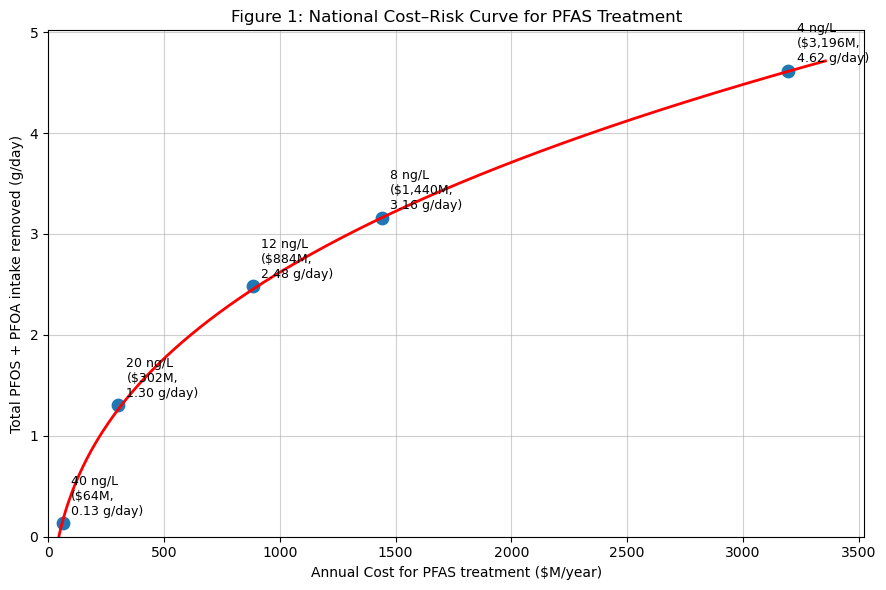

In [31]:
import numpy as np
import matplotlib.pyplot as plt


fig1_costs_M = np.array([national_costs_all_us[t] for t in threshold_ng])  # $M
fig1_exposure = np.array([scaled_pfas_exposure_by_threshold[t] / 1e9 for t in threshold_ng])  # g/day


x_curve_M = np.linspace(0, fig1_costs_M.max() * 1.05, 400)

# (Annual Cost is in $B) 
y_curve = -1.35 + 3.97 * ((x_curve_M/1000)  ** 0.35)

# --- Plot Figure 1 scatter + annotations ---
plt.figure(figsize=(9,6))
plt.scatter(fig1_costs_M, fig1_exposure, s=80)

for t, x, y in zip(threshold_ng, fig1_costs_M, fig1_exposure):
    label = f"{t} ng/L\n(${x:,.0f}M,\n{y:,.2f} g/day)"
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(6,6), fontsize=9)


plt.plot(x_curve_M, y_curve, color = 'red', linewidth=2)

plt.xlabel("Annual Cost for PFAS treatment ($M/year)")
plt.ylabel("Total PFOS + PFOA intake removed (g/day)")
plt.title("Figure 1: National Cost–Risk Curve for PFAS Treatment")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()


### Figure 1a: Average Per-Person PFAS Burden Proxy by Threshold
This figure shows the average PFAS burden proxy per person per day (ng/day/person) among populations served by entry points exceeding each regulatory threshold. As thresholds increase, fewer people remain affected, but those remaining experience higher average PFAS burden. The figure illustrates how PFAS burden becomes increasingly concentrated among affected populations.

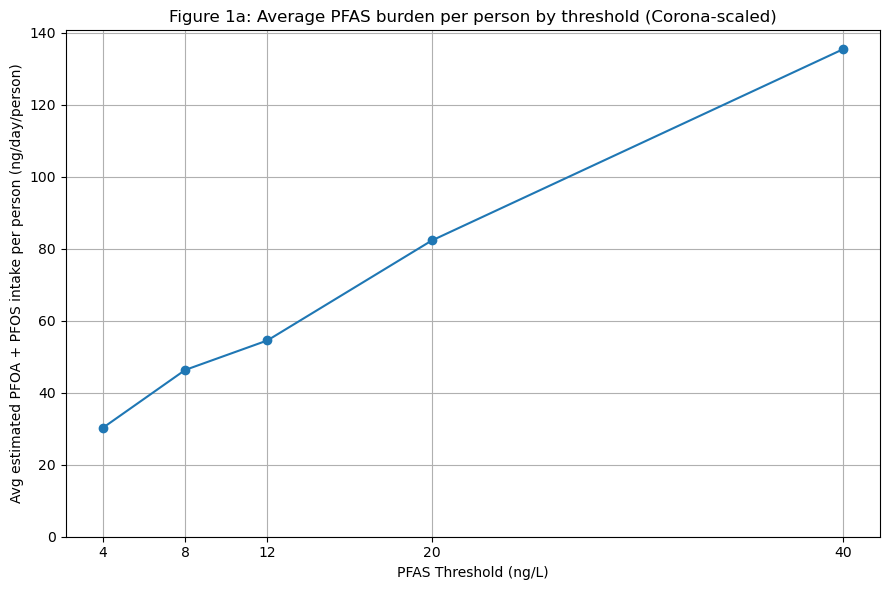

In [32]:
fig1a_exposure = [scaled_ng_day_per_person[t] for t in threshold_ng]  # ng/day/person (Corona-scaled)

plt.figure(figsize=(9,6))
plt.plot(threshold_ng, fig1a_exposure, marker='o')

plt.xlabel("PFAS Threshold (ng/L)")
plt.ylabel("Avg estimated PFOA + PFOS intake per person (ng/day/person)")
plt.title("Figure 1a: Average PFAS burden per person by threshold (Corona-scaled)")
plt.ylim(bottom=0)
plt.grid(True)
plt.xticks(threshold_ng)
plt.tight_layout()
plt.show()


### Figure 1b: Average Estimated PFOA + PFOS Concentration Among Treated Entry Points (Corona-Scaled)

This figure shows the Corona-scaled, population-weighted average combined PFAS concentration (PFOA + PFOS, ng/L) among entry points that would require treatment at each regulatory threshold. Concentrations are averaged across treated entry points using population served as weights.

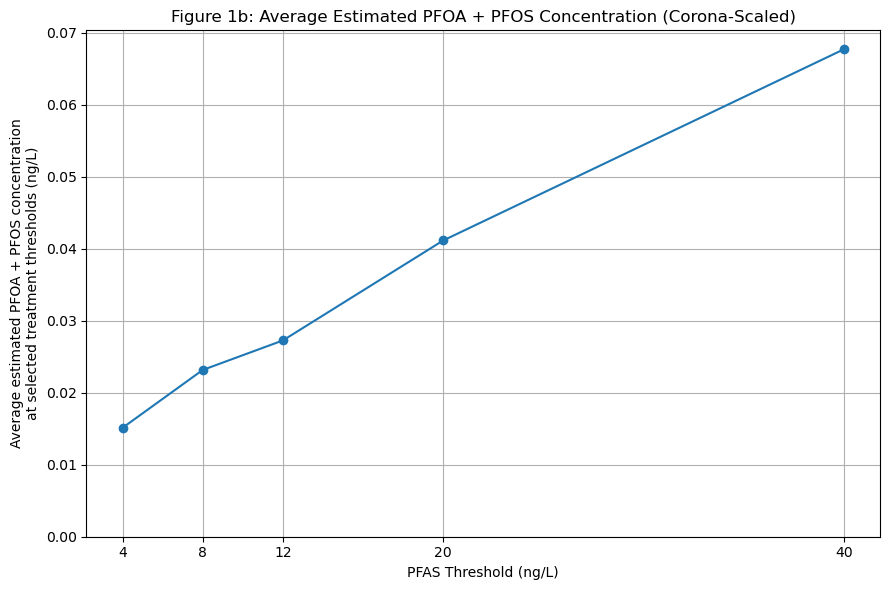

In [33]:
# Compute Corona-scaled, population-weighted mean concentration (ng/L) among systems treated at each threshold
scaled_avg_conc_by_threshold = {}

for t in threshold_ng:
    num = 0.0  # sum(total_pfas * population) scaled
    den = 0.0  # sum(population) scaled
    for _, row in comparison_scaled.iterrows():
        popbin = row['population_bin']
        scale = row['percent_of_corona_raw']
        if pd.isna(scale) or scale <= 0:
            continue
        bin_mask = (df['Population_bin'] == popbin)
        treated = df.loc[bin_mask, f'exceeds_{t}']
        pop = df.loc[bin_mask, 'Ep_Population']
        conc = df.loc[bin_mask, 'Total_PFAS']  # ng/L (PFOA+PFOS)

        bin_num = (conc * pop * treated).sum()
        bin_den = (pop * treated).sum()

        num += bin_num / scale
        den += bin_den / scale
    scaled_avg_conc_by_threshold[t] = (num / den) if den > 0 else 0

fig1b_conc = [scaled_avg_conc_by_threshold[t] for t in threshold_ng]

plt.figure(figsize=(9,6))
plt.plot(threshold_ng, fig1b_conc, marker='o')
plt.xlabel('PFAS Threshold (ng/L)')
plt.ylabel("Average estimated PFOA + PFOS concentration\nat selected treatment thresholds (ng/L)")
plt.title('Figure 1b: Average Estimated PFOA + PFOS Concentration (Corona-Scaled)')
plt.ylim(bottom=0)
plt.grid(True)
plt.xticks(threshold_ng)
plt.tight_layout()
plt.show()


### Figure 2: Cost-Effectiveness of PFAS Treatment by Threshold

Cost-effectiveness is expressed as dollars spent per gram of PFOA + PFOS burden removed. Both treatment costs and PFAS burden reductions are annualized, so the time dimension cancels, yielding cost per unit PFAS mass removed. Results are Corona-scaled and based on entry-point exceedances.

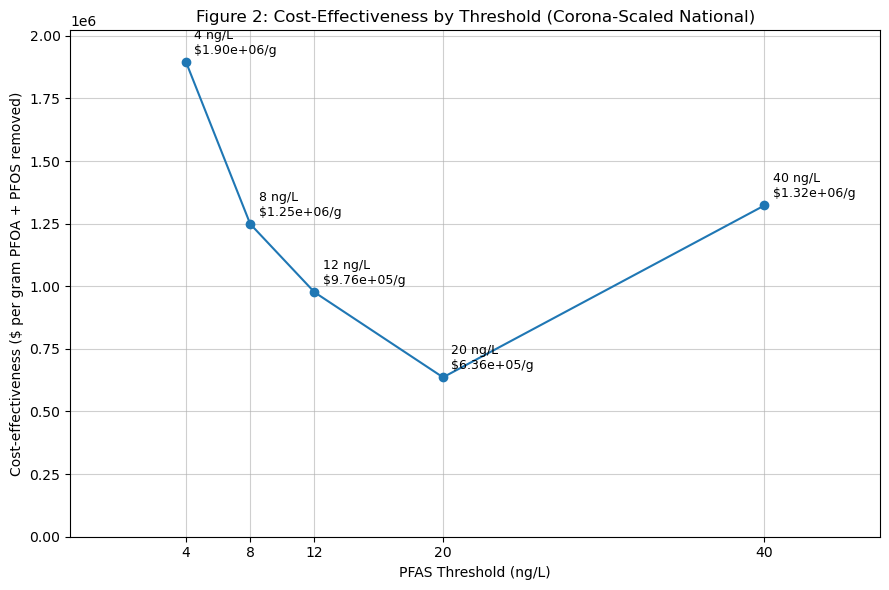

In [34]:
# cost_effectiveness is $M per ng removed (annual cost / annual removal; time cancels).
# Convert to $ per gram using 1e6 $/M and 1e9 ng/g.
ce_vals = [float(cost_effectiveness[t]) * 1e6 * 1e9 for t in threshold_ng]  # $ per gram

plt.figure(figsize=(9,6))
plt.plot(threshold_ng, ce_vals, marker='o')
plt.margins(x=0.2) 
plt.margins(y=0.1)

# Label each point with the threshold + value
for t, y in zip(threshold_ng, ce_vals):
    plt.annotate(
        f"{t} ng/L\n${y:,.2e}/g",
        (t, y),
        textcoords="offset points",
        xytext=(6,6),
        fontsize=9
    )

plt.xlabel("PFAS Threshold (ng/L)")
plt.ylabel("Cost-effectiveness ($ per gram PFOA + PFOS removed)")
plt.title("Figure 2: Cost-Effectiveness by Threshold (Corona-Scaled National)")
plt.ylim(bottom=0)
plt.grid(True, alpha=0.6)
plt.xticks(threshold_ng)
plt.tight_layout()
plt.show()

In [35]:
overall_exceedance = {}

total_systems = len(df)

for t in threshold_ng:
    col = f"exceeds_{t}"
    overall_exceedance[t] = df[col].mean() * 100   # % of entry points

### Figure 3: Percent of Entry Points Exceeding PFAS Thresholds

This figure shows (1) the percent of drinking-water entry points within each population bin that exceed each PFAS threshold, and (2) the overall percent of all U.S. entry points exceeding each threshold. Results are based on UCMR5 observations and reported for descriptive comparison across system sizes.


In [36]:
# compute percentage % exceeding per bin
exceed_by_bin = df.groupby("Population_bin")[[f"exceeds_{t}" for t in threshold_ng]].mean() * 100

# reorder bins properly if needed
bin_order = ['25 - 100','101 - 500','501 - 1,000','1,001 - 3,300',
             '3,301 - 10,000','10,001 - 50,000','50,001 - 100,000',
             '100,001 - 1,000,000','> 1,000,000']

exceed_by_bin = exceed_by_bin.reindex(bin_order)


<Figure size 1600x800 with 0 Axes>

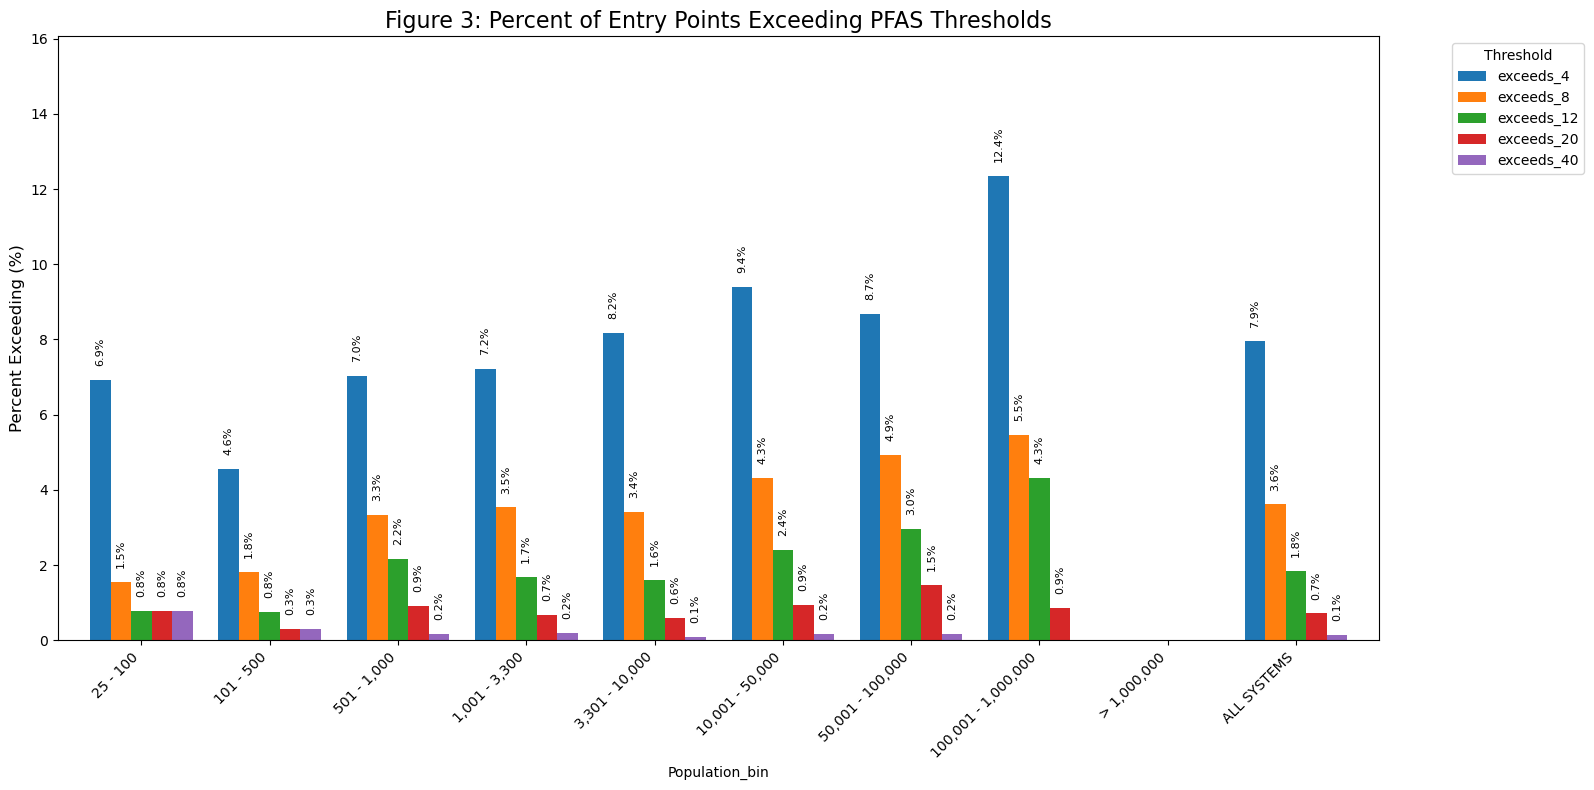

In [37]:
exceed_by_bin.loc["ALL SYSTEMS"] = [overall_exceedance[t] for t in threshold_ng]

plt.figure(figsize=(16, 8))
ax = exceed_by_bin.plot(kind='bar', figsize=(16, 8), width=0.8)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=8,
                    rotation=90,
                    xytext=(0, 10), 
                    textcoords='offset points')
        
plt.title("Figure 3: Percent of Entry Points Exceeding PFAS Thresholds", fontsize=16)
plt.ylabel("Percent Exceeding (%)", fontsize=12)
plt.ylim(0, exceed_by_bin.max().max() * 1.3) 
plt.xticks(rotation=45, ha='right')
plt.legend(title="Threshold", bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()


```ALL SYSTEMS``` is the national benchmark or the national average. It represents the big picture of the entire country, ignoring population size categories for a moment. It provides a point of comparison to determine if specific community sizes are disproportionately affected by PFAS contamination compared to the country at large.

In [38]:
# checking if any entry points with pop bin > 1,000,000 has exceeded any threshold
exceed_by_bin.loc["> 1,000,000"]

exceeds_4     0.0
exceeds_8     0.0
exceeds_12    0.0
exceeds_20    0.0
exceeds_40    0.0
Name: > 1,000,000, dtype: float64

In [39]:
# no. of entry points with pop bin > 1,000,000 
(df["Population_bin"] == "> 1,000,000").sum()

np.int64(6)

In [40]:
# all the entry point with pop bin > 1,000,000. did all of this cause the graph showed no bins
df.loc[df["Population_bin"] == "> 1,000,000"]

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng),annualized_cost($M)
8531,IL0316000,00001,0.0,0.0,0.0,2746388.0,1373194.0,"> 1,000,000",False,False,False,False,False,False,0.0,4.76
8532,IL0316000,00002,0.0,0.0,0.0,2746388.0,1373194.0,"> 1,000,000",False,False,False,False,False,False,0.0,4.76
17769,NY7003493,94001,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,4.76
17770,NY7003493,94002,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,4.76
17771,NY7003493,94003,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,4.76
17772,NY7003493,94004,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,4.76


The codes after the graph is to verify if the population bin more than 1 million didnt really have any Facility ID that exceeded any regulatory thresholds.

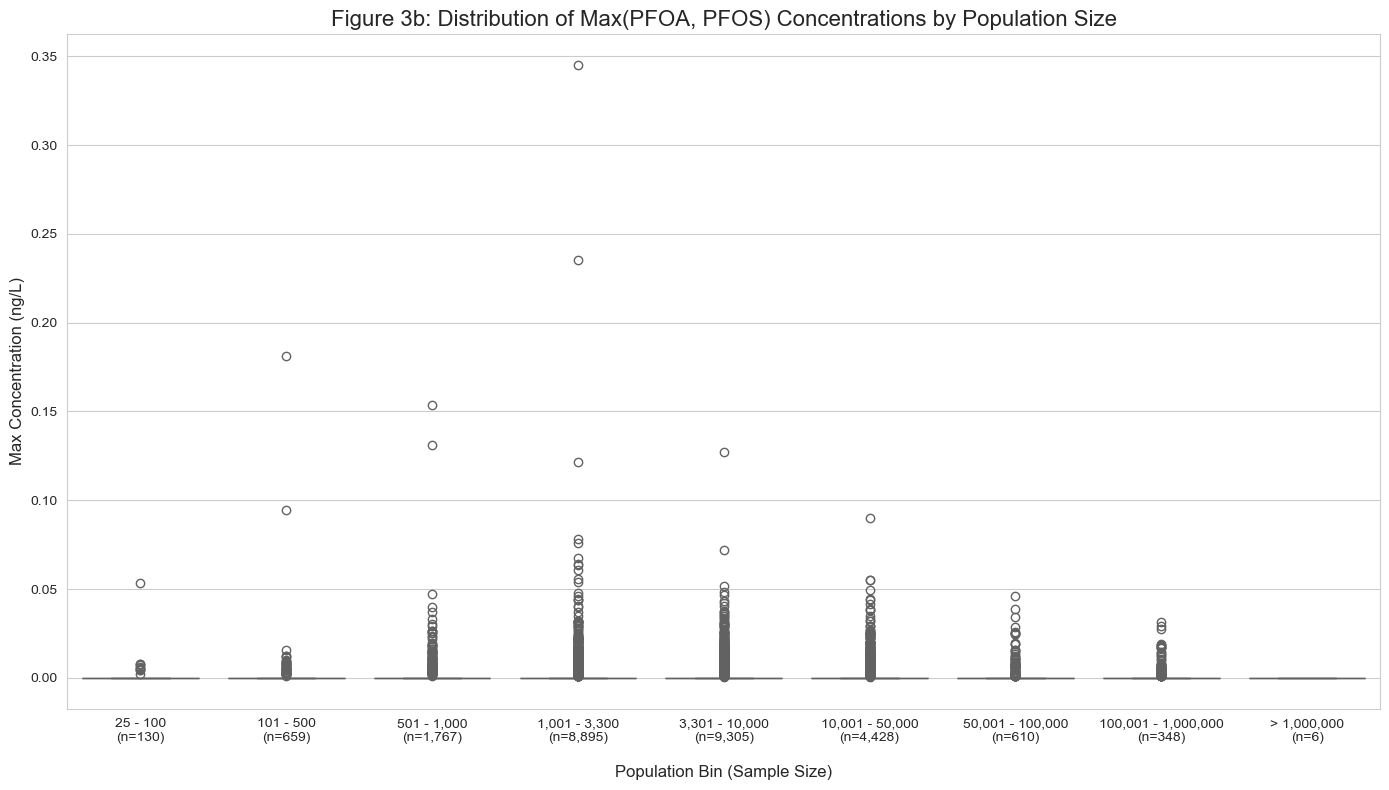

In [41]:
import seaborn as sns

df['max_pfas_conc'] = df[['PFOA', 'PFOS']].max(axis=1)

# Calculate counts
n_counts = df.groupby('Population_bin').size().reindex(bin_order)
new_x_labels = [f"{bin_name}\n(n={n_counts[bin_name]:,})" for bin_name in bin_order]

# Initialize Plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=df, 
    x='Population_bin', 
    y='max_pfas_conc', 
    order=bin_order,
    hue='Population_bin',
    legend=False,
    palette="Set3",
    showfliers=True
)

# Set the tick positions first, then the labels
ax.set_xticks(range(len(new_x_labels))) # This fixes the UserWarning
ax.set_xticklabels(new_x_labels)

# 6. Formatting
plt.title("Figure 3b: Distribution of Max(PFOA, PFOS) Concentrations by Population Size", fontsize=16)
plt.xlabel("Population Bin (Sample Size)", fontsize=12, labelpad=15)
plt.ylabel("Max Concentration (ng/L)", fontsize=12)

# If they still overlap horizontally, try rotation=45
plt.xticks(rotation=0) 


plt.tight_layout()
plt.show()